In [1]:
import networkx as nx
import numpy as np
from bngenerator import *
from matplotlib import pyplot as plt
from pgmpy.readwrite.XMLBeliefNetwork import XBNReader, XBNWriter
from pgmpy.readwrite import BIFWriter, BIFReader
from pgmpy.models import BayesianModel
from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination, ApproxInference, BeliefPropagation
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.estimators import BayesianEstimator
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BDeuScore, K2Score, BicScore
from pgmpy.metrics import structure_score
from pgmpy.utils import get_example_model
from pgmpy.estimators import ScoreCache
from pgmpy.inference.CausalInference import CausalInference
import random
import itertools
import numpy as np
import math
from same_decision_probability_calculation import *
from utils import *
from monte_carlo_sdp import *
import os
import glob
import time
import tracemalloc

# Loading models

In [2]:
def parse_bn_filename(filename):
    base = os.path.basename(filename).replace('.bif', '').replace('bn_', '')
    parts = base.split('_')
    n_nodes = int(parts[0].replace('n', ''))
    density = int(parts[1].replace('w', ''))
    # Take every remaining part as type_CPT, joined by underscores
    type_CPT = '_'.join(parts[2:])
    return n_nodes, density, type_CPT

def select_optimal_target_node(bn):
    """
    Selects a target node deeply embedded in the network (highest degree).
    Highly connected nodes provide a smooth, responsive probability gradient 
    for the Hill Climber, making extreme SDP values (0.90+) reachable.
    """
    best_node = None
    max_degree = -1
    
    for node in bn.nodes():
        # Ensure it's a binary node
        if len(bn.get_cpds(node).state_names[node]) != 2:
            continue
            
        degree = len(bn.get_parents(node)) + len(bn.get_children(node))
        if degree > max_degree:
            max_degree = degree
            best_node = node
            
    # Fallback if no binary nodes exist (rare)
    if best_node is None:
        return random.choice(list(bn.nodes()))
        
    return best_node

In [3]:
bif_directory = "./generated_bif_files/"
bif_files = glob.glob(os.path.join(bif_directory, "*.bif"))
print(f"Found {len(bif_files)} BIF files in {bif_directory}")

Found 262 BIF files in ./generated_bif_files/


In [4]:
model1 = BIFReader('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files/bn_n40_w6_rigid_extreme.bif').get_model()

In [5]:
model1.name = 'Low Entropy'

In [6]:
model2 = BIFReader('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files/bn_n40_w6_uncertain_strong.bif').get_model()

In [7]:
model2.name = 'High Entropy'

In [8]:
model3 = BIFReader('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files/bn_n40_w6_concentrated_bias_low.bif').get_model()
model3.name = 'Concentrated Bias (Low)'
model4 = BIFReader('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files/bn_n40_w6_concentrated_bias_high.bif').get_model()
model4.name = 'Concentrated Bias (High)'

# D-separation analysis

In [9]:
def analyse_active_trail_structure(model, target, evidence_vars, hidden_vars):
    """
    For each hidden variable, characterises its structural relationship
    to the target given the evidence.
    """
    results = {}

    for var in hidden_vars:
        is_active = model.is_dconnected(target, var, observed=evidence_vars)

        if not is_active:
            results[var] = {
                'status':       'd-separated',
                'min_path_len': None,
                'is_parent':    False,
                'is_ancestor':  False,
            }
            continue

        # Find shortest active path length via BFS on the moral graph
        # (approximate — true d-connected path length requires full BFS
        #  on the ADMG, but moral graph gives a useful proxy)
        ancestors_of_target = nx.ancestors(model, target) | {target}
        is_ancestor  = var in ancestors_of_target
        is_parent    = target in list(model.successors(var))

        # Shortest path in the undirected skeleton as a proxy for
        # path length (not accounting for direction — approximate)
        skeleton = model.to_undirected()
        try:
            min_path_len = nx.shortest_path_length(skeleton, var, target)
        except nx.NetworkXNoPath:
            min_path_len = None

        results[var] = {
            'status':       'd-connected',
            'min_path_len': min_path_len,
            'is_parent':    is_parent,
            'is_ancestor':  is_ancestor,
        }

    return results

In [10]:
for model in [model1]:
    target       = select_optimal_target_node(model)
    target_states = model.get_cpds(target).state_names[target]
    target_value  = target_states[1]

    # Pick a fixed arbitrary patient for the diagnostic run
    available = [n for n in model.nodes() if n != target]
    n_evidence = len(available) // 2
    target_sdps = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    harvested_data = find_exact_experimental_patients_random(model, target, target_value, 0.5,
                                                                    n_evidence, buckets=target_sdps, batch_size=10_000)
    for target_sdp, result in harvested_data.items():
        patient, sdp = result
        # compute number of d-separated hidden variables from target given evidence
        evidence_vars = [var for var in model.nodes() if var in patient and var != target]
        hidden_vars = [n for n in model.nodes() if n not in evidence_vars and n != target]
        dsep_count = sum(1 for var in hidden_vars if not model.is_dconnected(target, var, evidence_vars))
        
        
        print(f"Model: {model.name}, Target SDP: {target_sdp}, D-sep Hidden Vars: {dsep_count}, Evidence Vars: {len(evidence_vars)}, Patient: {patient}, SDP: {sdp:.4f}")

        #results = analyse_active_trail_structure(model, target, evidence_vars, hidden_vars)
        #for var, info in results.items():
        #    print(f"  Hidden Var: {var}, Status: {info['status']}, Min Path Len: {info['min_path_len']}, Is Parent: {info['is_parent']}, Is Ancestor: {info['is_ancestor']}")


Hunting for patients... (Locking 19 variables as evidence)
Generating batch 1/2 of 10000 random realities...
--> Filled bucket 1.0 with Exact SDP: 1.0000
--> Filled bucket 0.9 with Exact SDP: 0.9120
--> Filled bucket 0.6 with Exact SDP: 0.6175
--> Filled bucket 0.7 with Exact SDP: 0.7209
--> Filled bucket 0.8 with Exact SDP: 0.8395
--> Filled bucket 0.5 with Exact SDP: 0.5225
All buckets filled successfully!
Model: Low Entropy, Target SDP: 0.5, D-sep Hidden Vars: 3, Evidence Vars: 19, Patient: {'X14': '0', 'X9': '1', 'X24': '1', 'X15': '1', 'X13': '1', 'X33': '1', 'X5': '0', 'X37': '0', 'X10': '0', 'X23': '0', 'X30': '0', 'X25': '0', 'X18': '1', 'X36': '1', 'X2': '1', 'X16': '0', 'X11': '0', 'X3': '1', 'X32': '1'}, SDP: 0.5225
Model: Low Entropy, Target SDP: 0.6, D-sep Hidden Vars: 0, Evidence Vars: 19, Patient: {'X10': '0', 'X24': '0', 'X18': '0', 'X13': '0', 'X11': '1', 'X27': '1', 'X7': '1', 'X9': '1', 'X2': '1', 'X1': '1', 'X15': '1', 'X29': '1', 'X39': '0', 'X0': '1', 'X25': '1',

# Plain MCMC Diagnostics


--- Starting Hill Climbing Harvest for Buckets: [0.6] ---
    [+] HARVEST SUCCESS (Restart 1, Step 8): Filled bucket 0.6 (Exact SDP: 0.5868)!
--- Harvest Complete. All buckets filled successfully! ---

Running diagnostics for: Low Entropy
  Running chain 1/4...
  Running chain 2/4...
  Running chain 3/4...
  Running chain 4/4...


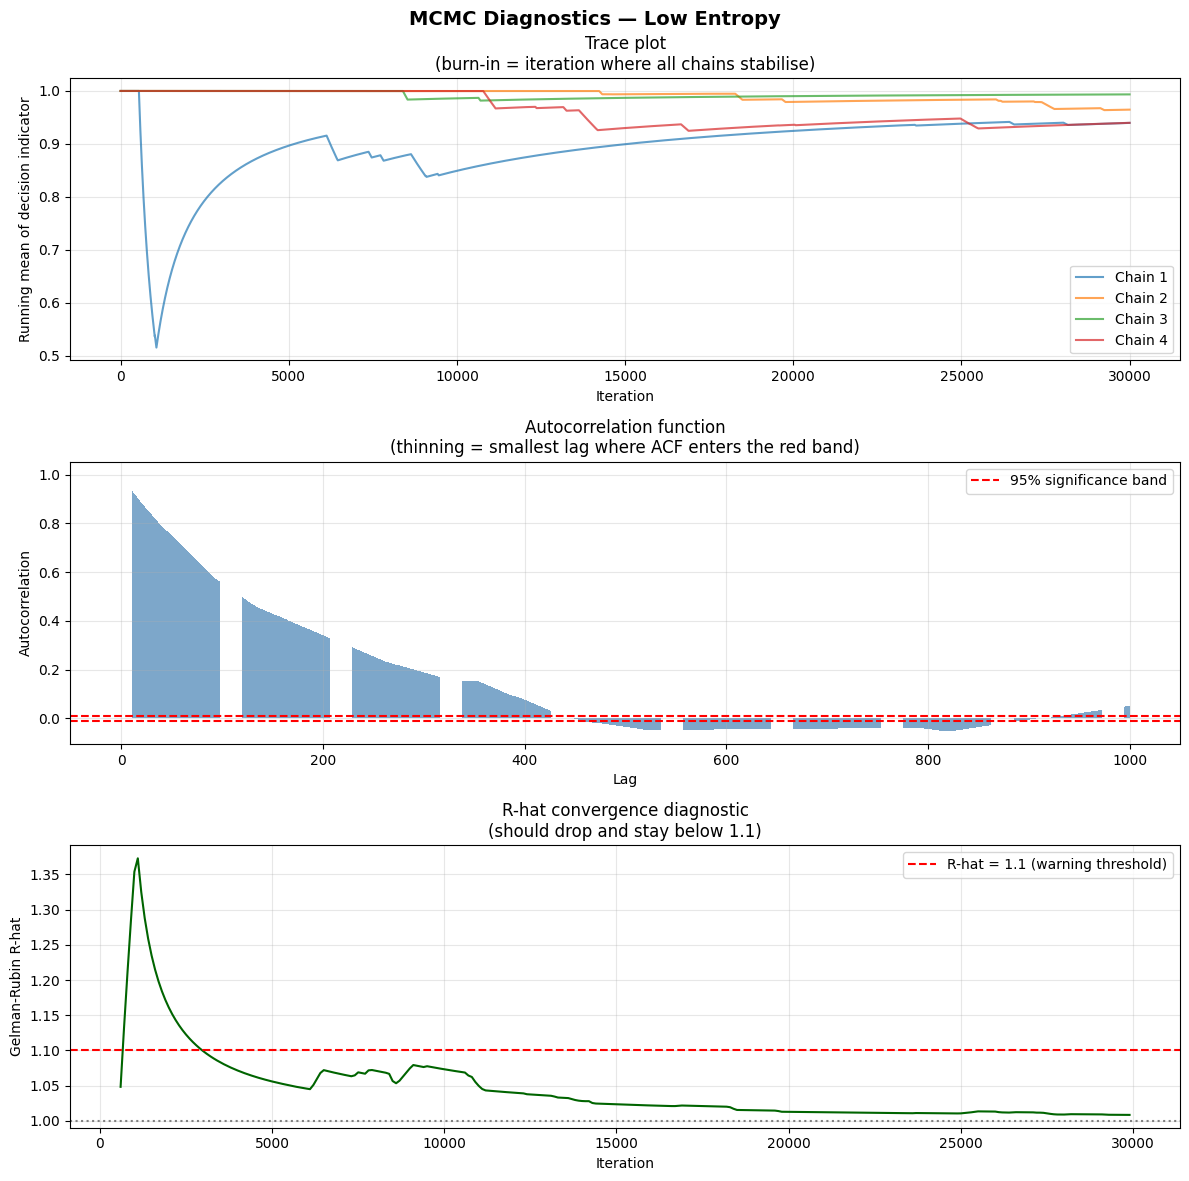


Network: Low Entropy
  Suggested burn-in  : 13672 iterations
  Suggested thinning : 442 iterations
  Final R-hat        : 1.0085  ✓ converged


--- Starting Hill Climbing Harvest for Buckets: [0.6] ---
    [+] HARVEST SUCCESS (Restart 0, Step 11): Filled bucket 0.6 (Exact SDP: 0.5820)!
--- Harvest Complete. All buckets filled successfully! ---

Running diagnostics for: High Entropy
  Running chain 1/4...
  Running chain 2/4...
  Running chain 3/4...
  Running chain 4/4...


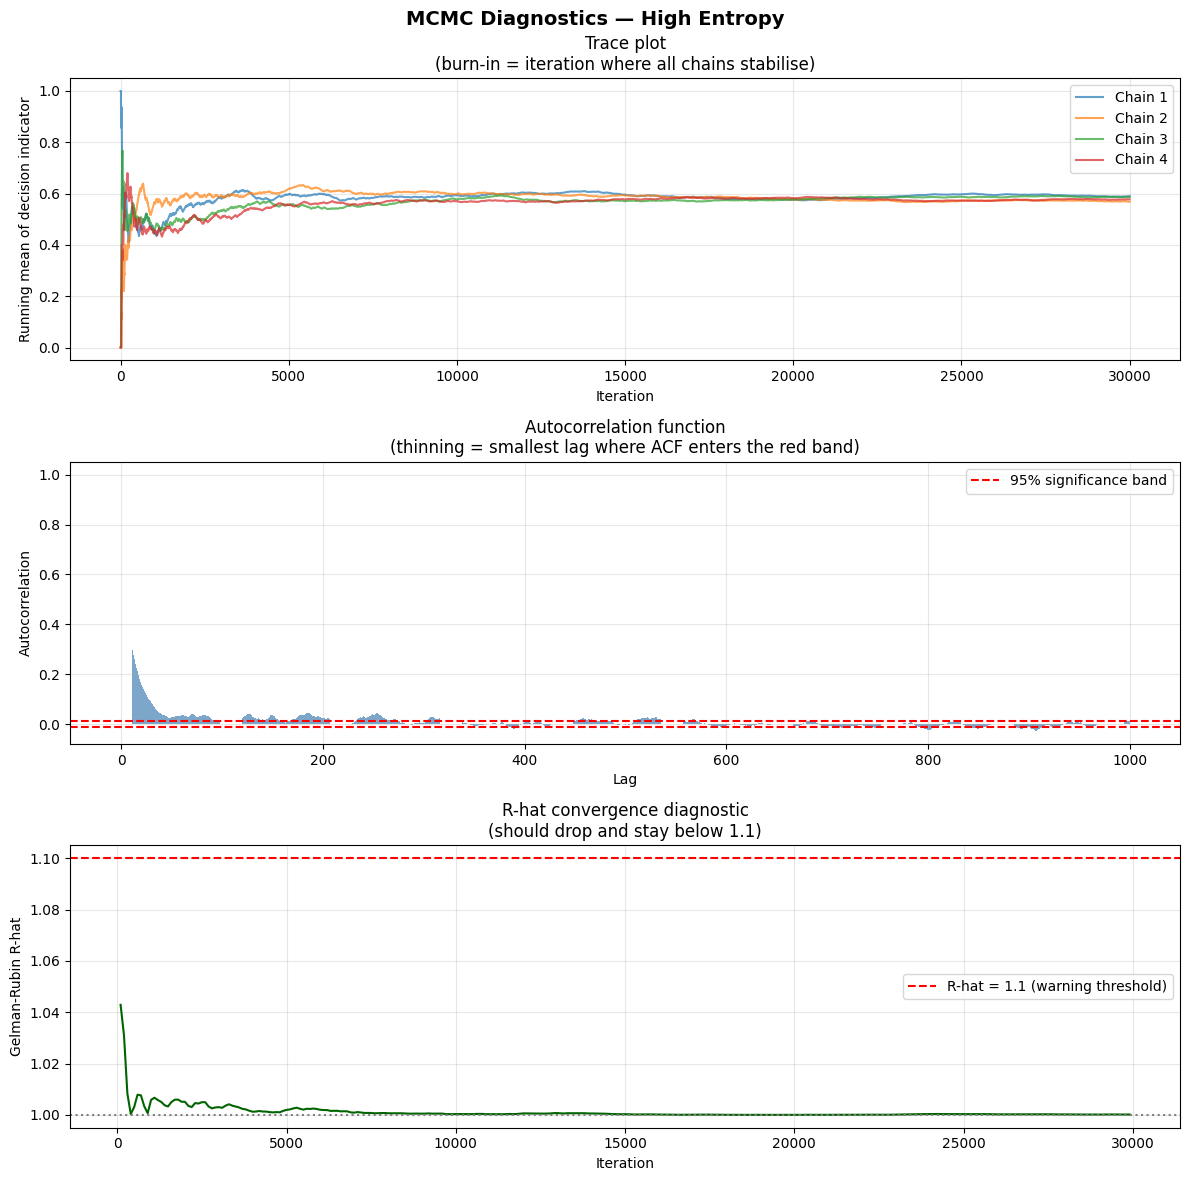


Network: High Entropy
  Suggested burn-in  : 3633 iterations
  Suggested thinning : 158 iterations
  Final R-hat        : 1.0001  ✓ converged


--- Starting Hill Climbing Harvest for Buckets: [0.6] ---
    [+] HARVEST SUCCESS (Restart 0, Step 2): Filled bucket 0.6 (Exact SDP: 0.6468)!
--- Harvest Complete. All buckets filled successfully! ---

Running diagnostics for: Concentrated Bias (Low)
  Running chain 1/4...
  Running chain 2/4...
  Running chain 3/4...
  Running chain 4/4...


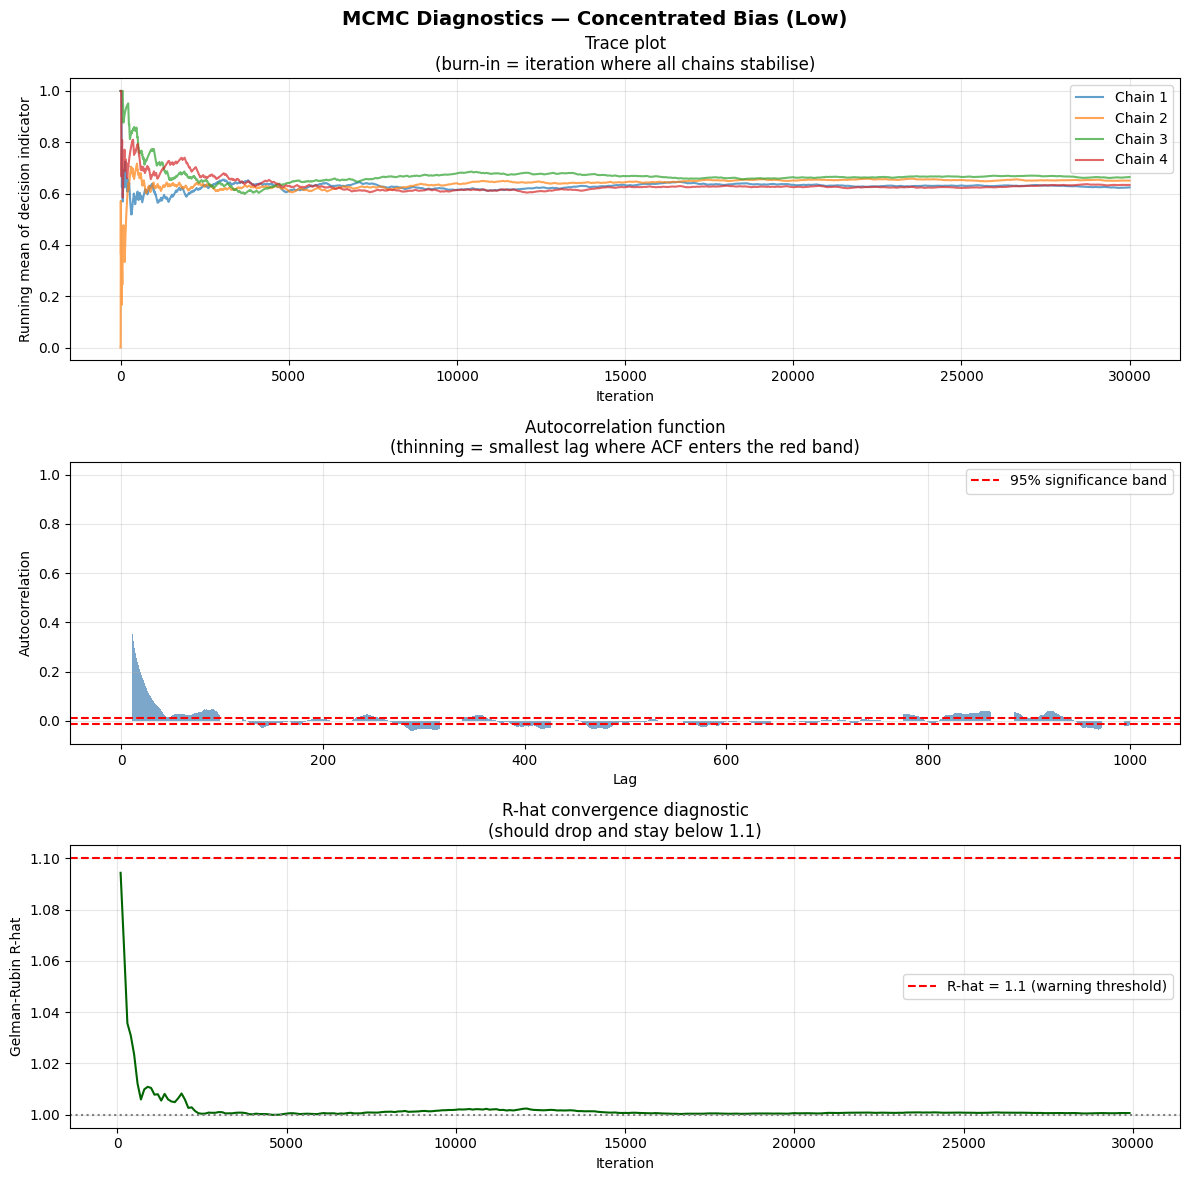


Network: Concentrated Bias (Low)
  Suggested burn-in  : 1069 iterations
  Suggested thinning : 120 iterations
  Final R-hat        : 1.0007  ✓ converged


--- Starting Hill Climbing Harvest for Buckets: [0.6] ---
    [+] HARVEST SUCCESS (Restart 0, Step 6): Filled bucket 0.6 (Exact SDP: 0.6173)!
--- Harvest Complete. All buckets filled successfully! ---

Running diagnostics for: Concentrated Bias (High)
  Running chain 1/4...
  Running chain 2/4...
  Running chain 3/4...
  Running chain 4/4...


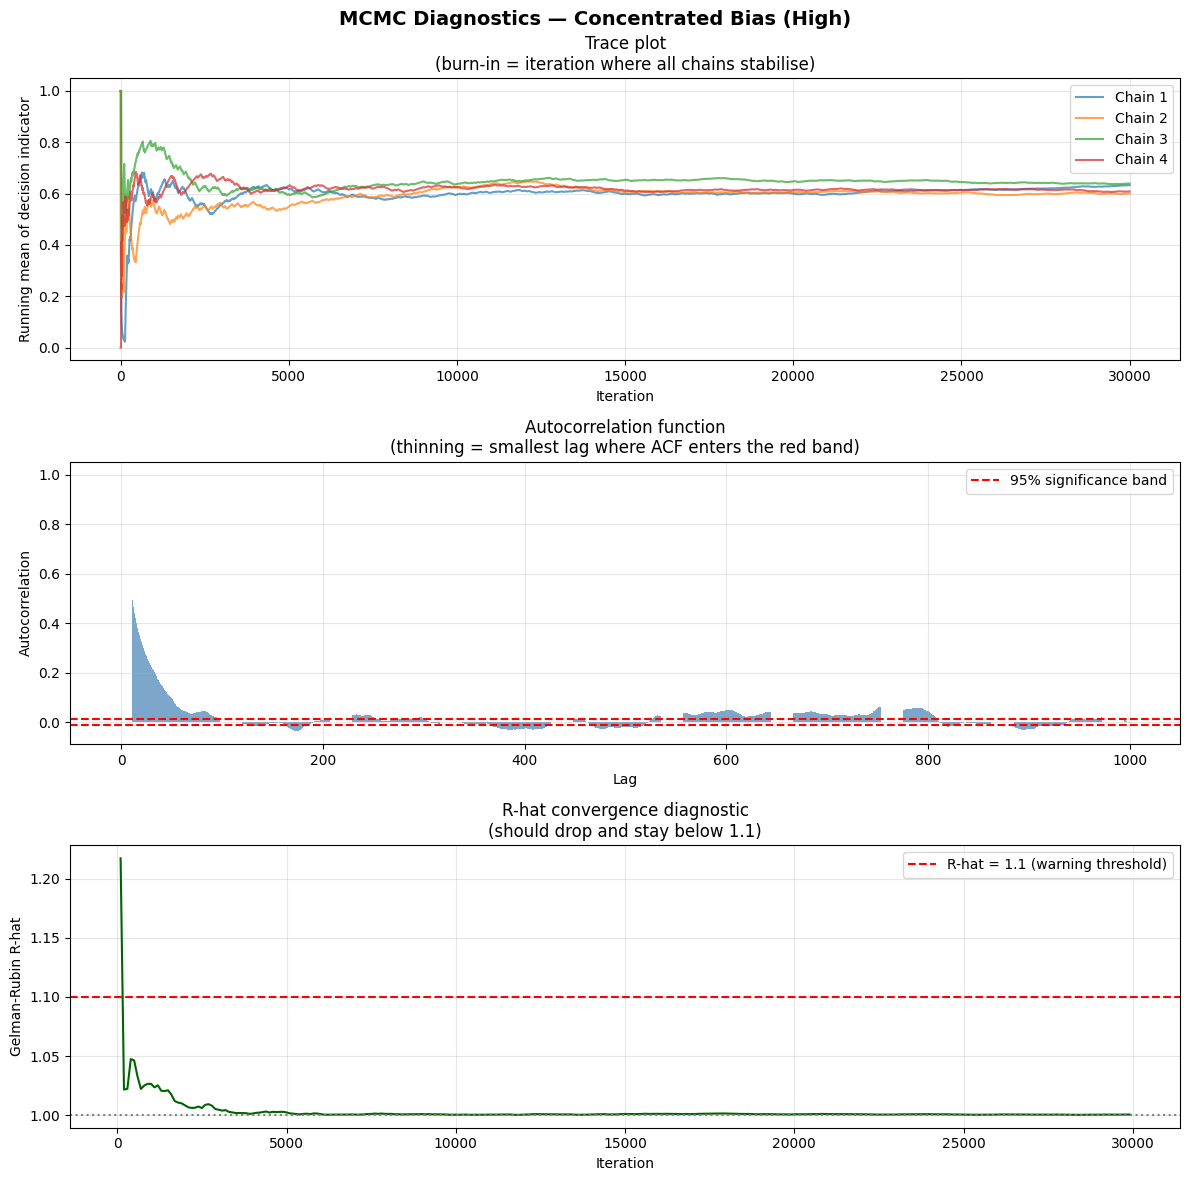


Network: Concentrated Bias (High)
  Suggested burn-in  : 3392 iterations
  Suggested thinning : 99 iterations
  Final R-hat        : 1.0007  ✓ converged



In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from pgmpy.models import BayesianNetwork
from pgmpy.sampling import BayesianModelSampling

def run_mcmc_diagnostics(bn, target, target_value, patient, threshold,
                          n_iterations=100000, n_chains=4):
    """
    Runs MCMC diagnostics to empirically determine burn-in and thinning.

    Produces three plots:
      1. Trace plot  — running decision fraction over iterations (per chain)
                       → shows when the chain stabilises (burn-in)
      2. Autocorrelation plot — ACF of the decision indicator series
                       → shows lag at which samples become independent (thinning)
      3. Multi-chain trace — all chains overlaid
                       → visual convergence check (Gelman-Rubin)
    """

    hidden_vars    = [n for n in bn.nodes() if n not in patient and n != target]
    target_states  = bn.get_cpds(target).state_names[target]
    cpd_cache      = {n: bn.get_cpds(n) for n in bn.nodes()}
    children_cache = {v: list(bn.get_children(v)) for v in hidden_vars}
    affected_cache = {v: [v] + children_cache[v] for v in hidden_vars}
    evidence_states = [State(var, val) for var, val in patient.items()]
    sampler         = BayesianModelSampling(bn)

    # ── Helpers (same as fast_mcmc_sdp_estimation) ────────────────────────────
    def full_log_joint(h_dict, t_state):
        full = {**h_dict, **patient, target: t_state}
        lp = 0.0
        for cpd in cpd_cache.values():
            p = cpd.get_value(**{v: full[v] for v in cpd.variables})
            if p == 0.0:
                return float('-inf')
            lp += math.log(p)
        return lp

    def log_sum_joints(lj_dict):
        vals = [v for v in lj_dict.values() if v != float('-inf')]
        if not vals:
            return float('-inf')
        m = max(vals)
        return m + math.log(sum(math.exp(v - m) for v in vals))

    def local_log_delta(var, old_val, new_val, h_dict, t_state):
        full_old = {**h_dict, **patient, target: t_state}
        full_new = {**full_old, var: new_val}
        delta = 0.0
        for node in affected_cache[var]:
            cpd   = cpd_cache[node]
            cvars = cpd.variables
            p_old = cpd.get_value(**{v: full_old[v] for v in cvars})
            p_new = cpd.get_value(**{v: full_new[v] for v in cvars})
            if p_new == 0.0:
                return float('-inf')
            if p_old == 0.0:
                return float('inf')
            delta += math.log(p_new) - math.log(p_old)
        return delta

    def get_seed():
        while True:
            seed_df = sampler.likelihood_weighted_sample(
                size=100, evidence=evidence_states, show_progress=False
            )
            valid = seed_df[seed_df['_weight'] > 0]
            if not valid.empty:
                w = valid['_weight'].values.astype(float)
                w /= w.sum()
                row = valid.iloc[np.random.choice(len(valid), p=w)]
                return {v: row[v] for v in hidden_vars}

    # ── Run n_chains independent chains, recording the raw decision signal ────
    all_chains = []   # each entry: list of 0/1 over n_iterations

    for chain_idx in range(n_chains):
        print(f"  Running chain {chain_idx + 1}/{n_chains}...")

        current_h     = get_seed()
        current_lj    = {t: full_log_joint(current_h, t) for t in target_states}
        current_log_p = log_sum_joints(current_lj)

        decisions = []

        for i in range(n_iterations):
            # MH step
            var     = random.choice(hidden_vars)
            cur_val = current_h[var]
            others  = [s for s in cpd_cache[var].state_names[var] if s != cur_val]
            if not others:
                pass
            else:
                new_val = random.choice(others)
                proposed_lj = {}
                recompute   = False
                for t in target_states:
                    if current_lj[t] == float('-inf'):
                        recompute = True; break
                    delta = local_log_delta(var, cur_val, new_val, current_h, t)
                    if delta == float('inf'):
                        recompute = True; break
                    proposed_lj[t] = current_lj[t] + delta
                if recompute:
                    tmp = {**current_h, var: new_val}
                    proposed_lj = {t: full_log_joint(tmp, t) for t in target_states}

                proposed_log_p = log_sum_joints(proposed_lj)
                log_alpha      = proposed_log_p - current_log_p

                if log_alpha >= 0 or (
                    proposed_log_p != float('-inf') and
                    math.log(random.random()) < log_alpha
                ):
                    current_h[var] = new_val
                    current_lj     = proposed_lj
                    current_log_p  = proposed_log_p

            # Record decision at this iteration
            full_ev  = {**patient, **current_h}
            p_target = get_exact_target_posterior_O1(bn, target, target_value, full_ev)
            decisions.append(1 if p_target >= threshold else 0)

        all_chains.append(decisions)

    all_chains = np.array(all_chains, dtype=float)  # (n_chains, n_iterations)

    # ═════════════════════════════════════════════════════════════════════════
    # PLOT 1: Trace plot — running mean of decision indicator (burn-in)
    # The running mean should stabilise → read off burn-in as the point
    # where all chains have converged to a stable level.
    # ═════════════════════════════════════════════════════════════════════════
    running_means = np.cumsum(all_chains, axis=1) / (np.arange(1, n_iterations + 1))

    fig, axes = plt.subplots(3, 1, figsize=(12, 12))

    ax = axes[0]
    for c in range(n_chains):
        ax.plot(running_means[c], alpha=0.7, label=f'Chain {c+1}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Running mean of decision indicator')
    ax.set_title('Trace plot\n'
                 '(burn-in = iteration where all chains stabilise)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ═════════════════════════════════════════════════════════════════════════
    # PLOT 2: Autocorrelation function of chain 0 — thinning
    # Thinning = smallest lag where ACF drops below significance band.
    # ═════════════════════════════════════════════════════════════════════════
    MAX_LAG    = 1000
    signal     = all_chains[0] - all_chains[0].mean()
    acf_values = np.correlate(signal, signal, mode='full')
    acf_values = acf_values[len(acf_values) // 2:]
    acf_values /= acf_values[0]

    significance = 1.96 / math.sqrt(n_iterations)  # 95% band under H0: no autocorr

    ax = axes[1]
    lags = np.arange(MAX_LAG)
    ax.bar(lags, acf_values[:MAX_LAG], color='steelblue', alpha=0.7)
    ax.axhline( significance, color='red', linestyle='--', label='95% significance band')
    ax.axhline(-significance, color='red', linestyle='--')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('Autocorrelation function\n'
                 '(thinning = smallest lag where ACF enters the red band)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ═════════════════════════════════════════════════════════════════════════
    # PLOT 3: Gelman-Rubin R-hat over time
    # R-hat ≈ 1.0 means chains have converged to the same distribution.
    # R-hat > 1.1 is the standard warning threshold.
    # ═════════════════════════════════════════════════════════════════════════
    rhat_values = []
    check_points = range(100, n_iterations, 100)

    for t in check_points:
        chains_t = all_chains[:, :t]
        n        = chains_t.shape[1]
        m        = n_chains
        chain_means  = chains_t.mean(axis=1)           # (m,)
        grand_mean   = chain_means.mean()
        B            = n / (m - 1) * np.sum((chain_means - grand_mean) ** 2)
        W            = np.mean(np.var(chains_t, axis=1, ddof=1))
        var_hat      = (1 - 1/n) * W + B / n
        rhat         = math.sqrt(var_hat / W) if W > 0 else float('nan')
        rhat_values.append(rhat)

    ax = axes[2]
    ax.plot(list(check_points), rhat_values, color='darkgreen')
    ax.axhline(1.1, color='red', linestyle='--', label='R-hat = 1.1 (warning threshold)')
    ax.axhline(1.0, color='gray', linestyle=':')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Gelman-Rubin R-hat')
    ax.set_title('R-hat convergence diagnostic\n'
                 '(should drop and stay below 1.1)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'MCMC Diagnostics — {bn.name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Print suggested parameters ────────────────────────────────────────────
    # Burn-in: first iteration where ALL running means are within 5% of final value
    final_means  = running_means[:, -1]
    stable       = np.all(
        np.abs(running_means - final_means[:, None]) < 0.05, axis=0
    )
    suggested_burnin = int(np.argmax(stable)) if stable.any() else n_iterations // 2

    # Thinning: first lag where ACF < significance threshold
    below = np.where(np.abs(acf_values[1:MAX_LAG]) < significance)[0]
    suggested_thinning = int(below[0]) + 1 if len(below) > 0 else MAX_LAG

    print(f"\n{'='*50}")
    print(f"Network: {bn.name}")
    print(f"  Suggested burn-in  : {suggested_burnin} iterations")
    print(f"  Suggested thinning : {suggested_thinning} iterations")
    print(f"  Final R-hat        : {rhat_values[-1]:.4f}"
          f"  {'✓ converged' if rhat_values[-1] < 1.1 else '✗ NOT converged'}")
    print(f"{'='*50}\n")

    return {
        'burn_in':   suggested_burnin,
        'thinning':  suggested_thinning,
        'rhat':      rhat_values[-1],
        'chains':    all_chains,
    }


# ── Run on both synthetic networks ────────────────────────────────────────────
for model in [model1, model2, model3, model4]:
    target       = select_optimal_target_node(model)
    target_states = model.get_cpds(target).state_names[target]
    target_value  = target_states[1]

    # Pick a fixed arbitrary patient for the diagnostic run
    available = [n for n in model.nodes() if n != target]
    evidence_vars = random.sample(available, k=len(available) // 2)
    #patient = {
    #    var: random.choice(model.get_cpds(var).state_names[var])
    #    for var in evidence_vars
    #}

    target_sdp = 0.6
    harvested_data = harvest_patients_for_all_buckets(model, target, target_value, 0.5, evidence_vars, [target_sdp])
    result = harvested_data[target_sdp]
    patient, _ = result

    print(f"\nRunning diagnostics for: {model.name}")
    if model.name == 'Low Entropy':
        
        diag = run_mcmc_diagnostics(
            model, target, target_value, patient, threshold=0.5,
            n_iterations=30_000, n_chains=4
        )
    else:
        diag = run_mcmc_diagnostics(
            model, target, target_value, patient, threshold=0.5,
            n_iterations=30_000, n_chains=4
        )

# Parallel Tempering Diagnostics

In [12]:
from bn_entropy import *


--- Starting Hill Climbing Harvest for Buckets: [0.6] ---
    [+] HARVEST SUCCESS (Restart 0, Step 9): Filled bucket 0.6 (Exact SDP: 0.5683)!
--- Harvest Complete. All buckets filled successfully! ---

Running PT-MH diagnostics for: Low Entropy
  H_norm=0.3182 → using max_temp=40.00
  Temperatures: [ 1.    3.42 11.7  40.  ]


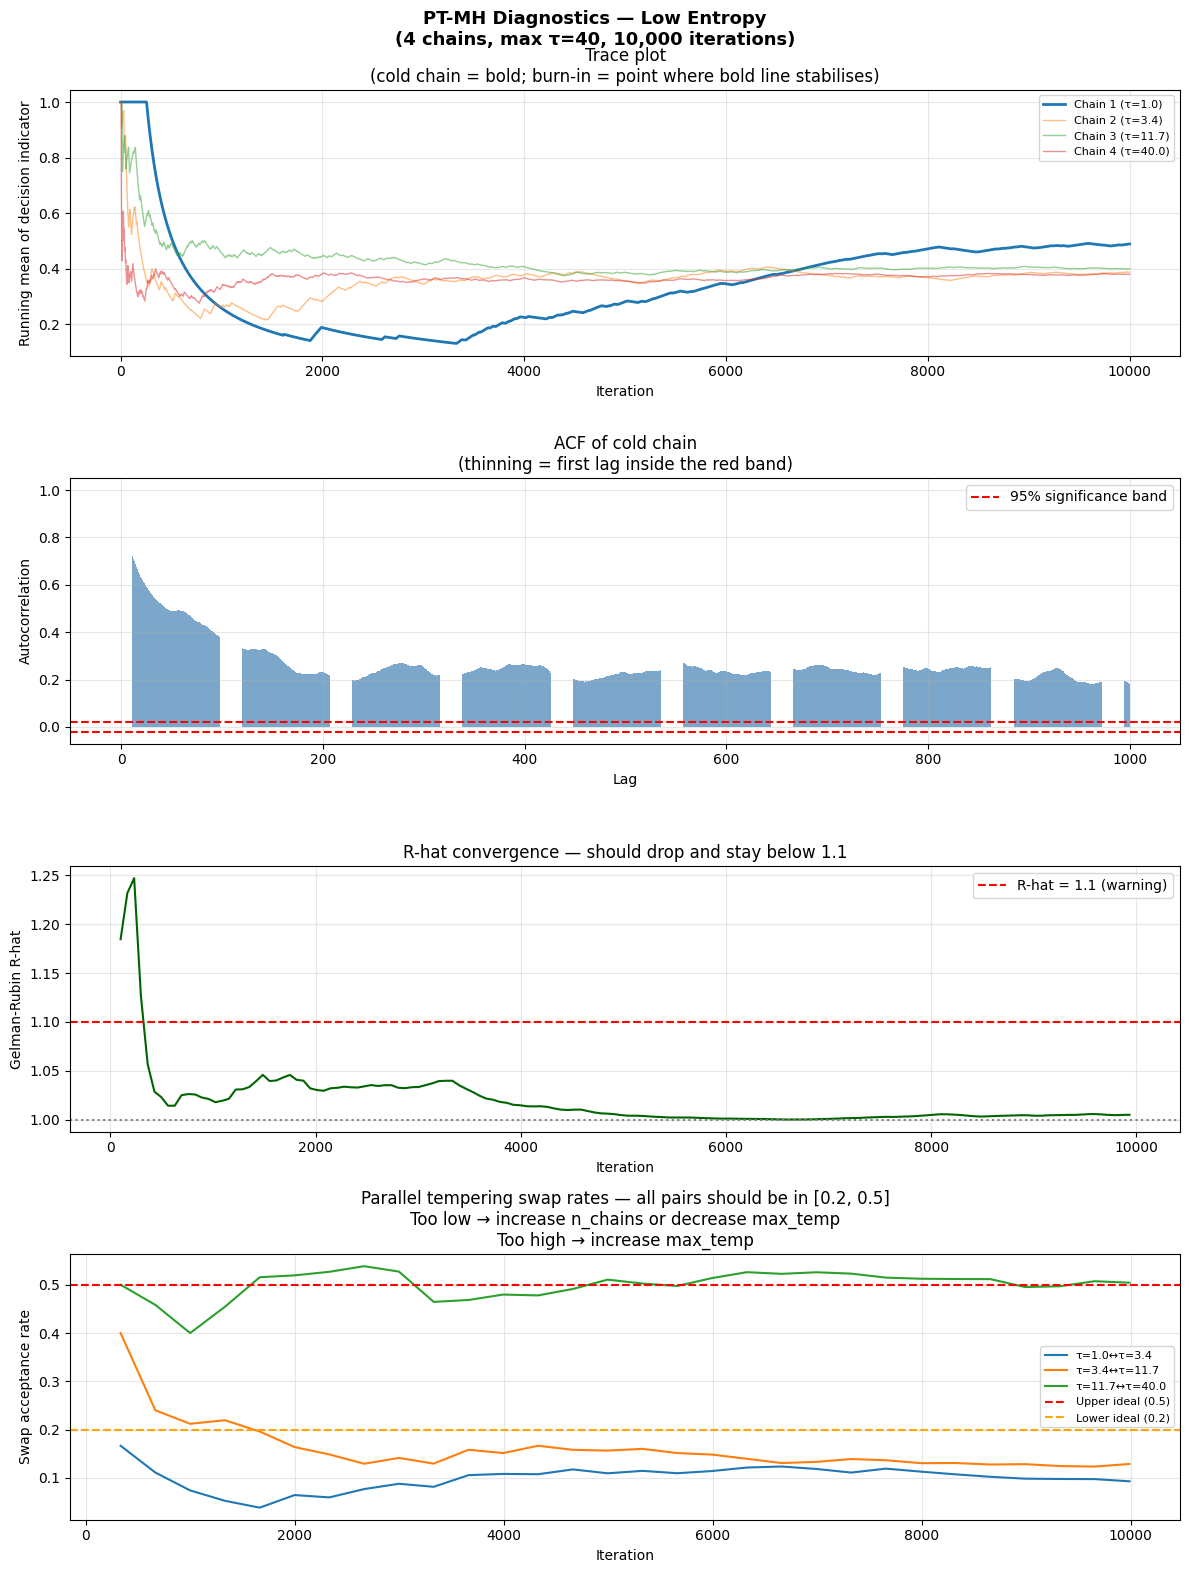


Network            : Low Entropy
Temperatures       : [ 1.    3.42 11.7  40.  ]
Suggested burn-in  : 478
Suggested thinning : 1000
Final R-hat        : 1.0050  ✓ converged
  Swap τ=1.0↔τ=3.4 : 0.093  ✗ adjust max_temp
  Swap τ=3.4↔τ=11.7 : 0.129  ✗ adjust max_temp
  Swap τ=11.7↔τ=40.0 : 0.503  ✗ adjust max_temp


--- Starting Hill Climbing Harvest for Buckets: [0.6] ---
    [+] INSTANT HARVEST (Restart 0): Filled bucket 0.6 with SDP 0.5591!
--- Harvest Complete. All buckets filled successfully! ---

Running PT-MH diagnostics for: High Entropy
  H_norm=0.9628 → using max_temp=40.00
  Temperatures: [ 1.    3.42 11.7  40.  ]


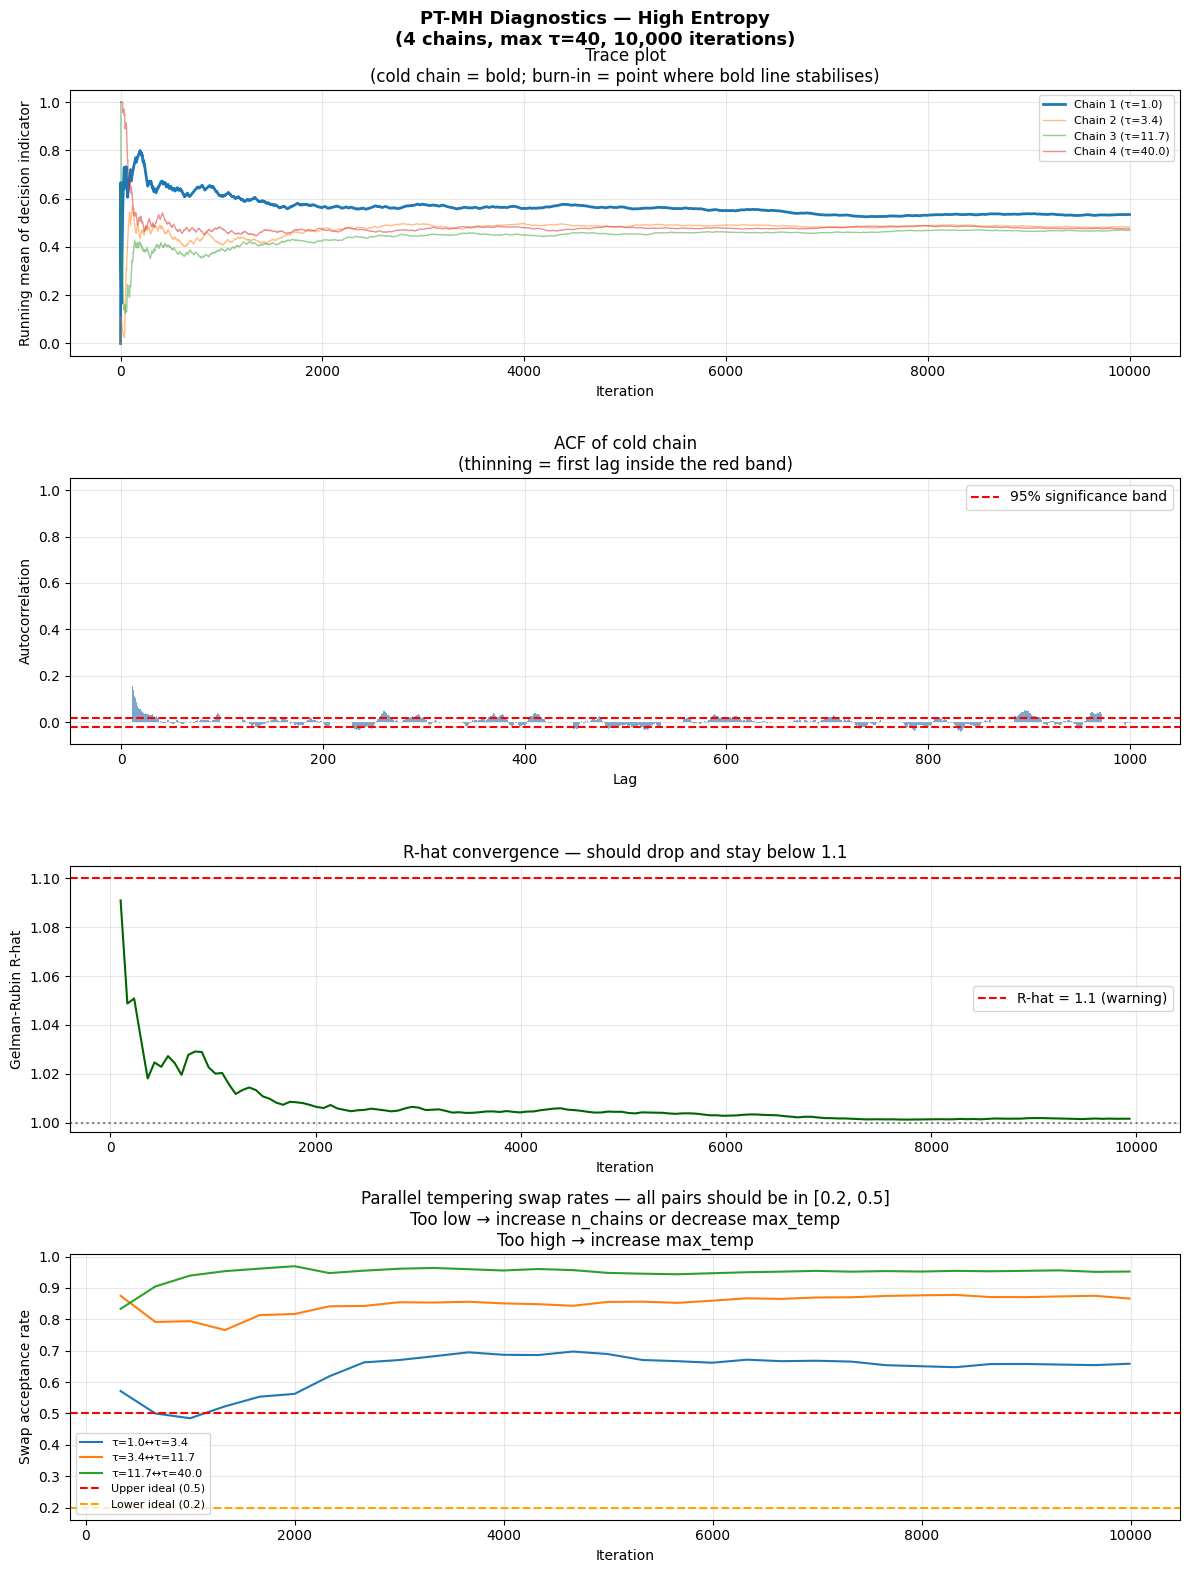


Network            : High Entropy
Temperatures       : [ 1.    3.42 11.7  40.  ]
Suggested burn-in  : 1
Suggested thinning : 37
Final R-hat        : 1.0017  ✓ converged
  Swap τ=1.0↔τ=3.4 : 0.657  ✗ adjust max_temp
  Swap τ=3.4↔τ=11.7 : 0.866  ✗ adjust max_temp
  Swap τ=11.7↔τ=40.0 : 0.952  ✗ adjust max_temp


--- Starting Hill Climbing Harvest for Buckets: [0.6] ---
    [+] HARVEST SUCCESS (Restart 0, Step 6): Filled bucket 0.6 (Exact SDP: 0.5567)!
--- Harvest Complete. All buckets filled successfully! ---

Running PT-MH diagnostics for: Concentrated Bias (Low)
  H_norm=0.5731 → using max_temp=40.00
  Temperatures: [ 1.    3.42 11.7  40.  ]


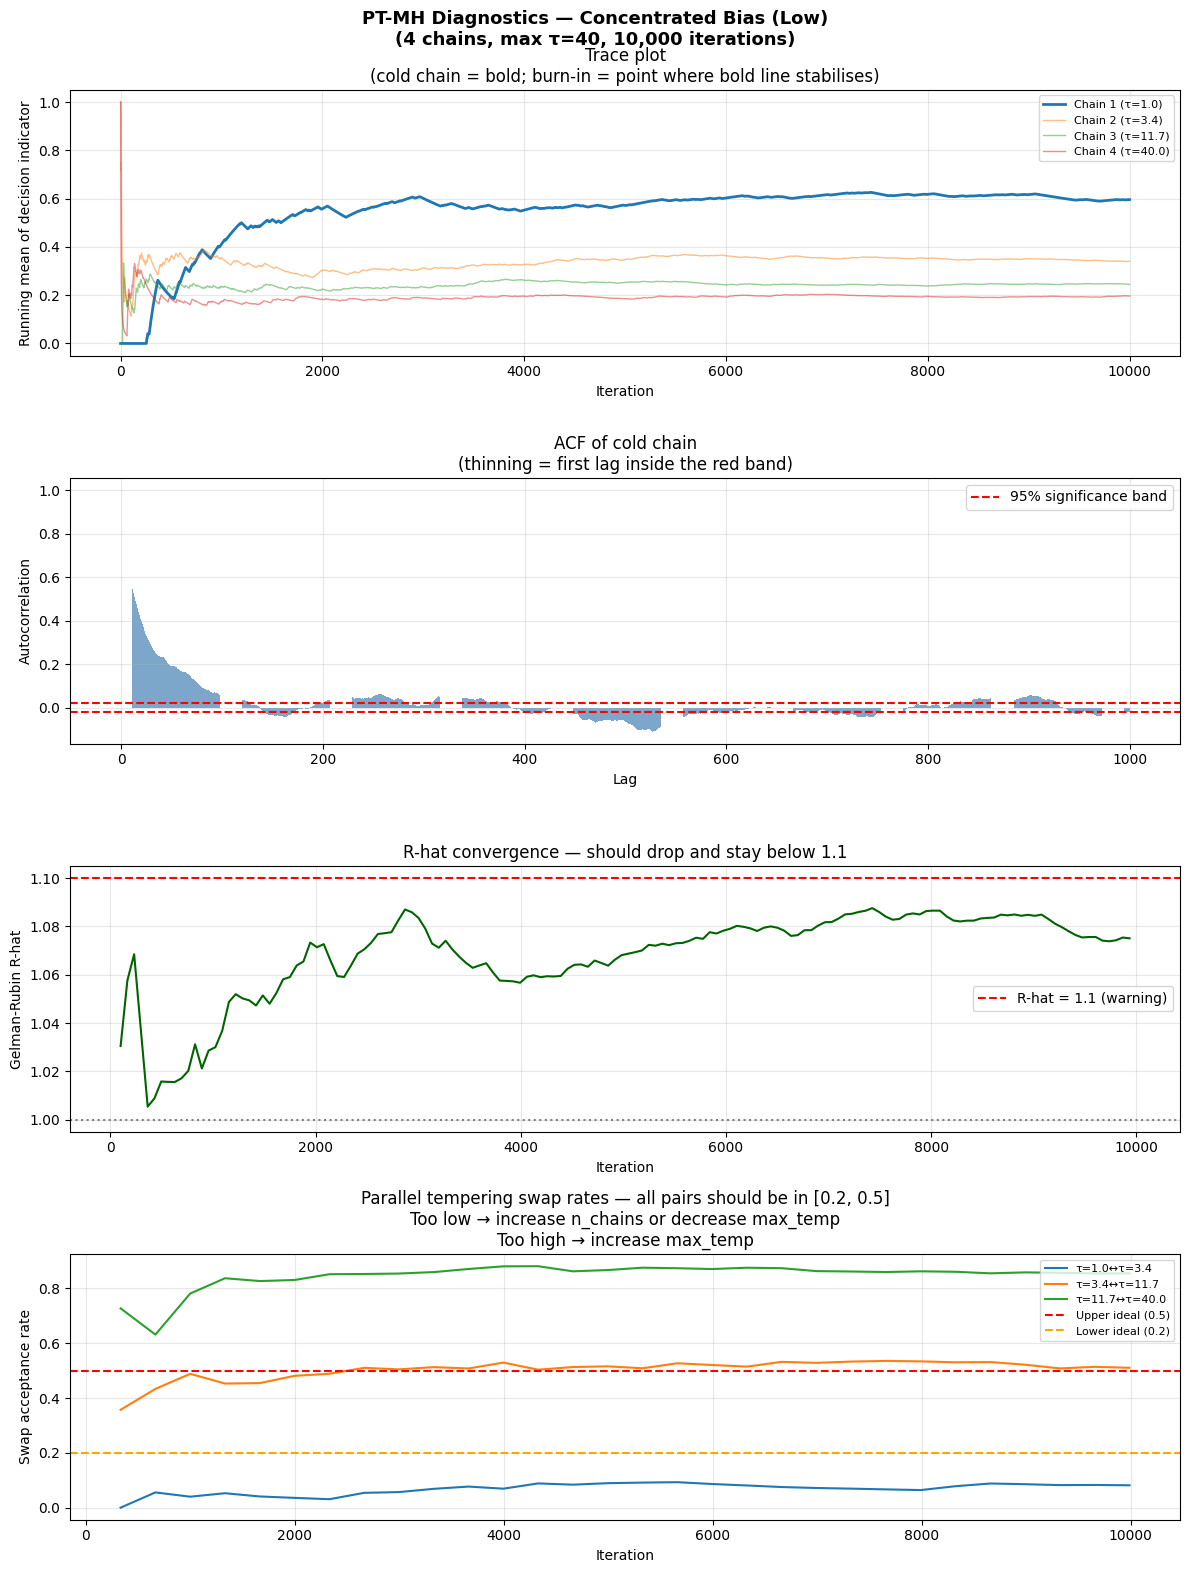


Network            : Concentrated Bias (Low)
Temperatures       : [ 1.    3.42 11.7  40.  ]
Suggested burn-in  : 1801
Suggested thinning : 112
Final R-hat        : 1.0751  ✓ converged
  Swap τ=1.0↔τ=3.4 : 0.081  ✗ adjust max_temp
  Swap τ=3.4↔τ=11.7 : 0.510  ✗ adjust max_temp
  Swap τ=11.7↔τ=40.0 : 0.855  ✗ adjust max_temp


--- Starting Hill Climbing Harvest for Buckets: [0.6] ---
    [+] HARVEST SUCCESS (Restart 0, Step 7): Filled bucket 0.6 (Exact SDP: 0.5653)!
--- Harvest Complete. All buckets filled successfully! ---

Running PT-MH diagnostics for: Concentrated Bias (High)
  H_norm=0.5629 → using max_temp=40.00
  Temperatures: [ 1.    3.42 11.7  40.  ]


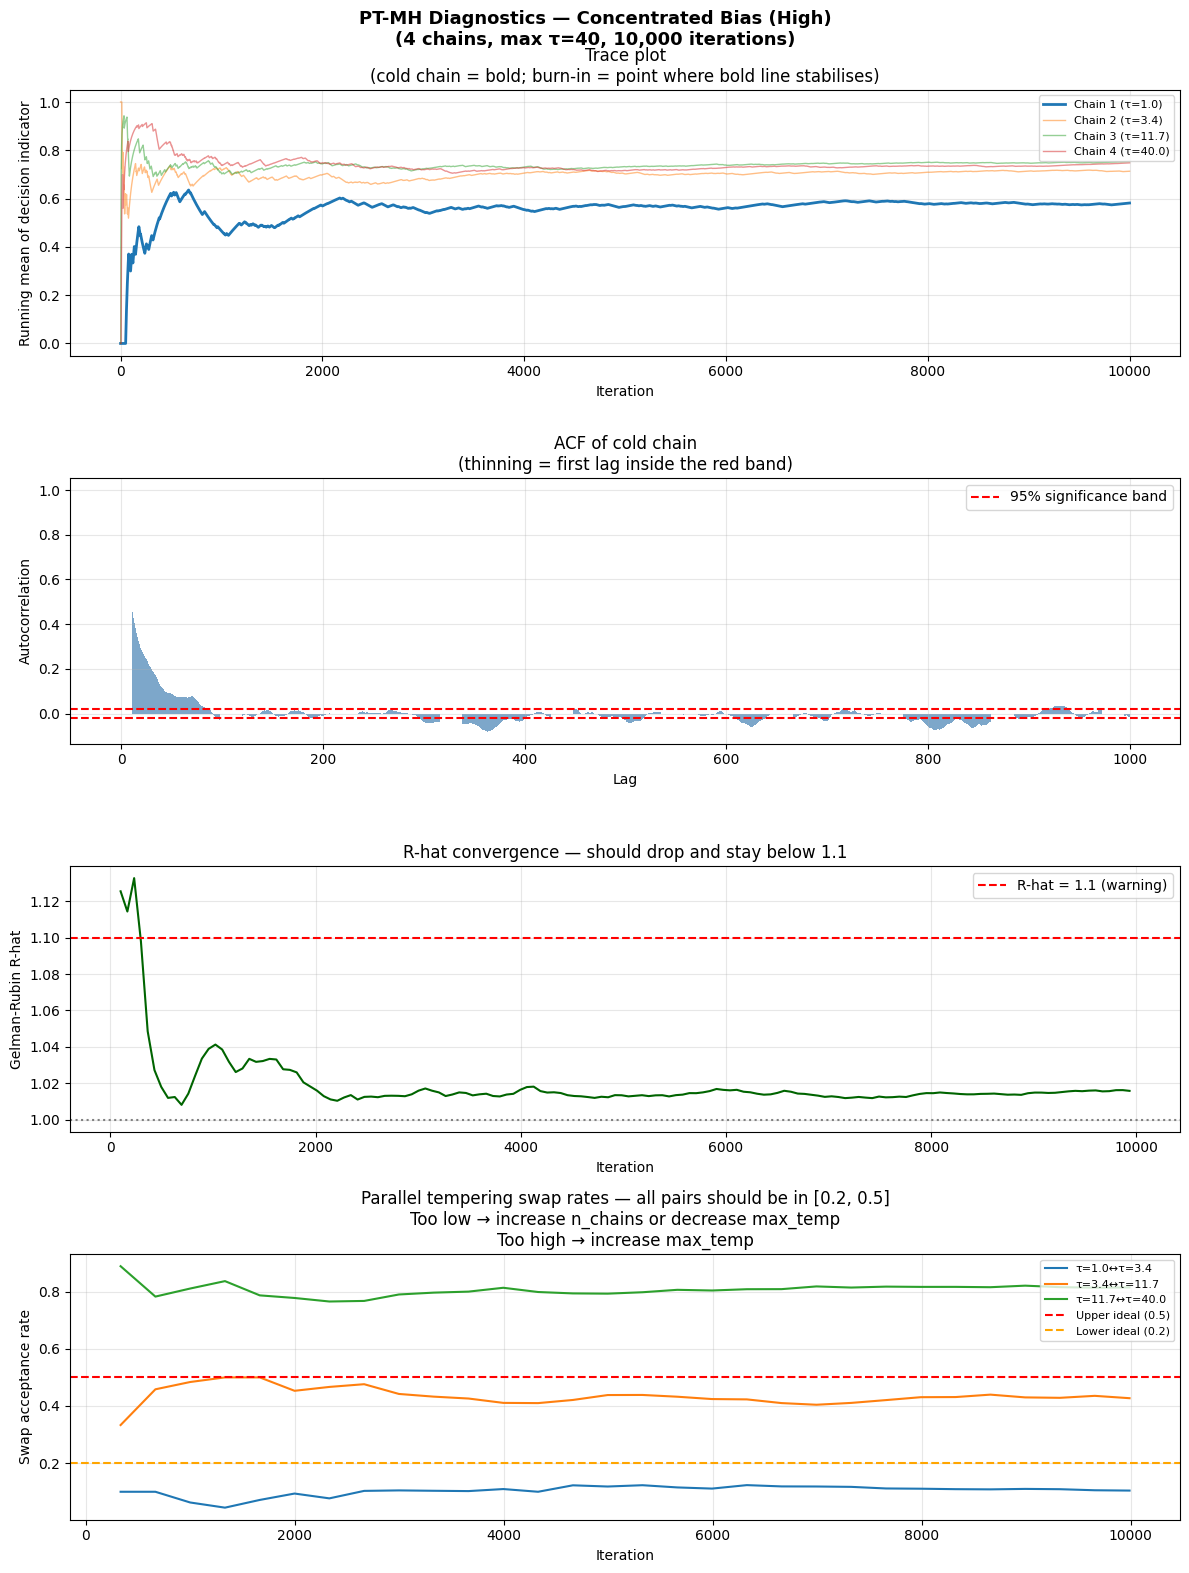


Network            : Concentrated Bias (High)
Temperatures       : [ 1.    3.42 11.7  40.  ]
Suggested burn-in  : 401
Suggested thinning : 87
Final R-hat        : 1.0158  ✓ converged
  Swap τ=1.0↔τ=3.4 : 0.104  ✗ adjust max_temp
  Swap τ=3.4↔τ=11.7 : 0.427  ✓
  Swap τ=11.7↔τ=40.0 : 0.815  ✗ adjust max_temp



In [13]:
def run_pt_mcmc_diagnostics(bn, target, target_value, patient, threshold,
                             n_iterations=15000, n_chains=4, max_temp=10.0):
    """
    Runs MCMC diagnostics using MH + Parallel Tempering only (no Gibbs).

    Produces four plots:
      1. Trace plot       — running decision fraction per chain (burn-in)
      2. Autocorrelation  — ACF of cold chain decision indicator (thinning)
      3. R-hat over time  — Gelman-Rubin convergence across chains
      4. Swap acceptance  — per-temperature-pair swap rate over time
    """

    hidden_vars     = [n for n in bn.nodes() if n not in patient and n != target]
    target_states   = bn.get_cpds(target).state_names[target]
    cpd_cache       = {n: bn.get_cpds(n) for n in bn.nodes()}
    children_cache  = {v: list(bn.get_children(v)) for v in hidden_vars}
    affected_cache  = {v: [v] + children_cache[v] for v in hidden_vars}
    evidence_states = [State(var, val) for var, val in patient.items()]
    sampler         = BayesianModelSampling(bn)

    temps = np.geomspace(1.0, max_temp, n_chains)

    # ── Helpers ───────────────────────────────────────────────────────────────

    def full_log_joint(h_dict, t_state):
        full = {**h_dict, **patient, target: t_state}
        lp = 0.0
        for cpd in cpd_cache.values():
            p = cpd.get_value(**{v: full[v] for v in cpd.variables})
            if p == 0.0:
                return float('-inf')
            lp += math.log(p)
        return lp

    def log_sum_joints(lj_dict):
        vals = [v for v in lj_dict.values() if v != float('-inf')]
        if not vals:
            return float('-inf')
        m = max(vals)
        return m + math.log(sum(math.exp(v - m) for v in vals))

    def local_log_delta(var, old_val, new_val, h_dict, t_state):
        full_old = {**h_dict, **patient, target: t_state}
        full_new = {**full_old, var: new_val}
        delta = 0.0
        for node in affected_cache[var]:
            cpd   = cpd_cache[node]
            cvars = cpd.variables
            p_old = cpd.get_value(**{v: full_old[v] for v in cvars})
            p_new = cpd.get_value(**{v: full_new[v] for v in cvars})
            if p_new == 0.0:
                return float('-inf')
            if p_old == 0.0:
                return float('inf')
            delta += math.log(p_new) - math.log(p_old)
        return delta

    def get_seed():
        while True:
            seed_df = sampler.likelihood_weighted_sample(
                size=100, evidence=evidence_states, show_progress=False
            )
            valid = seed_df[seed_df['_weight'] > 0]
            if not valid.empty:
                w = valid['_weight'].values.astype(float)
                w /= w.sum()
                row = valid.iloc[np.random.choice(len(valid), p=w)]
                return {v: row[v] for v in hidden_vars}

    # ── Initialise chains ─────────────────────────────────────────────────────
    print(f"  Temperatures: {np.round(temps, 2)}")
    chains     = [get_seed() for _ in range(n_chains)]
    chain_ljs  = [{t: full_log_joint(h, t) for t in target_states} for h in chains]
    chain_logp = [log_sum_joints(lj) for lj in chain_ljs]

    # ── Storage for diagnostics ───────────────────────────────────────────────
    decisions          = [[] for _ in range(n_chains)]
    n_pairs            = n_chains - 1
    swap_attempts      = np.zeros(n_pairs, dtype=int)
    swap_accepts       = np.zeros(n_pairs, dtype=int)
    swap_rate_history  = []
    SWAP_SNAPSHOT_FREQ = max(1, n_iterations // 30)

    # ── Main loop ─────────────────────────────────────────────────────────────
    for i in range(n_iterations):

        # Step 1: Tempered MH update for every chain
        for c in range(n_chains):
            var     = random.choice(hidden_vars)
            cur_val = chains[c][var]
            others  = [s for s in cpd_cache[var].state_names[var] if s != cur_val]
            if not others:
                continue
            new_val = random.choice(others)

            proposed_lj = {}
            recompute   = False
            for t in target_states:
                if chain_ljs[c][t] == float('-inf'):
                    recompute = True
                    break
                delta = local_log_delta(var, cur_val, new_val, chains[c], t)
                if delta == float('inf'):
                    recompute = True
                    break
                proposed_lj[t] = chain_ljs[c][t] + delta

            if recompute:
                tmp         = {**chains[c], var: new_val}
                proposed_lj = {t: full_log_joint(tmp, t) for t in target_states}

            proposed_log_p = log_sum_joints(proposed_lj)

            # Tempered acceptance ratio
            log_alpha = (proposed_log_p - chain_logp[c]) / temps[c]
            if log_alpha >= 0 or (
                proposed_log_p != float('-inf') and
                math.log(random.random()) < log_alpha
            ):
                chains[c][var]  = new_val
                chain_ljs[c]    = proposed_lj
                chain_logp[c]   = proposed_log_p

        # Step 2: Parallel tempering swap
        if i % 10 == 0 and n_chains > 1:
            c1 = random.randint(0, n_pairs - 1)
            c2 = c1 + 1
            swap_attempts[c1] += 1

            log_alpha_swap = (
                (1.0 / temps[c1] - 1.0 / temps[c2]) *
                (chain_logp[c2] - chain_logp[c1])
            )
            if log_alpha_swap >= 0 or math.log(random.random()) < log_alpha_swap:
                chains[c1],     chains[c2]     = chains[c2],     chains[c1]
                chain_ljs[c1],  chain_ljs[c2]  = chain_ljs[c2],  chain_ljs[c1]
                chain_logp[c1], chain_logp[c2] = chain_logp[c2], chain_logp[c1]
                swap_accepts[c1] += 1

        # Step 3: Record decision indicator for all chains
        for c in range(n_chains):
            full_ev = {**patient, **chains[c]}
            p       = get_exact_target_posterior_O1(bn, target, target_value, full_ev)
            decisions[c].append(1 if p >= threshold else 0)

        # Snapshot swap rates
        if (i + 1) % SWAP_SNAPSHOT_FREQ == 0:
            rates = np.where(
                swap_attempts > 0,
                swap_accepts / swap_attempts,
                np.nan
            )
            swap_rate_history.append((i + 1, rates.copy()))

    decisions  = np.array(decisions, dtype=float)   # (n_chains, n_iterations)
    cold_chain = decisions[0]

    # ═════════════════════════════════════════════════════════════════════════
    # PLOTS
    # ═════════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(4, 1, figsize=(12, 16))

    # ── Plot 1: Trace (burn-in) ───────────────────────────────────────────────
    running_means = np.cumsum(decisions, axis=1) / np.arange(1, n_iterations + 1)
    ax = axes[0]
    for c in range(n_chains):
        ax.plot(running_means[c],
                alpha=1.0 if c == 0 else 0.5,
                lw=2.0 if c == 0 else 1.0,
                label=f'Chain {c+1} (τ={temps[c]:.1f})')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Running mean of decision indicator')
    ax.set_title('Trace plot\n'
                 '(cold chain = bold; burn-in = point where bold line stabilises)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Plot 2: ACF of cold chain (thinning) ─────────────────────────────────
    MAX_LAG      = 1000
    signal       = cold_chain - cold_chain.mean()
    acf_full     = np.correlate(signal, signal, mode='full')
    acf_vals     = acf_full[len(acf_full) // 2:]
    acf_vals     = acf_vals / acf_vals[0]
    significance = 1.96 / math.sqrt(n_iterations)

    ax = axes[1]
    ax.bar(np.arange(MAX_LAG), acf_vals[:MAX_LAG], color='steelblue', alpha=0.7)
    ax.axhline( significance, color='red', linestyle='--', label='95% significance band')
    ax.axhline(-significance, color='red', linestyle='--')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('ACF of cold chain\n'
                 '(thinning = first lag inside the red band)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Plot 3: Gelman-Rubin R-hat over time ─────────────────────────────────
    rhat_values  = []
    check_step   = max(1, n_iterations // 150)
    check_points = range(max(n_chains + 1, 100), n_iterations, check_step)

    for t in check_points:
        chains_t    = decisions[:, :t]
        n, m        = chains_t.shape[1], n_chains
        chain_means = chains_t.mean(axis=1)
        grand_mean  = chain_means.mean()
        B           = n / (m - 1) * np.sum((chain_means - grand_mean) ** 2)
        W           = np.mean(np.var(chains_t, axis=1, ddof=1))
        var_hat     = (1 - 1 / n) * W + B / n
        rhat_values.append(math.sqrt(var_hat / W) if W > 0 else float('nan'))

    ax = axes[2]
    ax.plot(list(check_points), rhat_values, color='darkgreen')
    ax.axhline(1.1, color='red',  linestyle='--', label='R-hat = 1.1 (warning)')
    ax.axhline(1.0, color='gray', linestyle=':')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Gelman-Rubin R-hat')
    ax.set_title('R-hat convergence — should drop and stay below 1.1')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Plot 4: Swap acceptance rates per temperature pair ───────────────────
    ax = axes[3]
    if swap_rate_history:
        iters           = [s[0] for s in swap_rate_history]
        rates_over_time = np.array([s[1] for s in swap_rate_history])
        for p_idx in range(n_pairs):
            ax.plot(iters, rates_over_time[:, p_idx],
                    label=f'τ={temps[p_idx]:.1f}↔τ={temps[p_idx+1]:.1f}')
    ax.axhline(0.5, color='red',    linestyle='--', label='Upper ideal (0.5)')
    ax.axhline(0.2, color='orange', linestyle='--', label='Lower ideal (0.2)')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Swap acceptance rate')
    ax.set_title('Parallel tempering swap rates — all pairs should be in [0.2, 0.5]\n'
                 'Too low → increase n_chains or decrease max_temp\n'
                 'Too high → increase max_temp')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'PT-MH Diagnostics — {bn.name}\n'
        f'({n_chains} chains, max τ={max_temp}, {n_iterations:,} iterations)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    # ── Suggested parameters ──────────────────────────────────────────────────
    final_mean   = running_means[0, -1]
    stable       = np.abs(running_means[0] - final_mean) < 0.05
    suggested_burnin = int(np.argmax(stable)) if stable.any() else n_iterations // 2

    below = np.where(np.abs(acf_vals[1:MAX_LAG]) < significance)[0]
    suggested_thinning = int(below[0]) + 1 if len(below) > 0 else MAX_LAG

    final_rhat       = rhat_values[-1] if rhat_values else float('nan')
    final_swap_rates = (swap_accepts /
                        np.where(swap_attempts > 0, swap_attempts, 1))

    print(f"\n{'='*55}")
    print(f"Network            : {bn.name}")
    print(f"Temperatures       : {np.round(temps, 2)}")
    print(f"Suggested burn-in  : {suggested_burnin}")
    print(f"Suggested thinning : {suggested_thinning}")
    print(f"Final R-hat        : {final_rhat:.4f}  "
          f"{'✓ converged' if final_rhat < 1.1 else '✗ NOT converged'}")
    for p_idx, rate in enumerate(final_swap_rates):
        status = '✓' if 0.2 <= rate <= 0.5 else '✗ adjust max_temp'
        print(f"  Swap τ={temps[p_idx]:.1f}↔τ={temps[p_idx+1]:.1f} "
              f": {rate:.3f}  {status}")
    print(f"{'='*55}\n")

    return {
        'burn_in':     suggested_burnin,
        'thinning':    suggested_thinning,
        'rhat':        final_rhat,
        'swap_rates':  final_swap_rates,
        'chains':      decisions,
    }


# ── Run on both synthetic networks ────────────────────────────────────────────
for model in [model1, model2, model3, model4]:
    target        = select_optimal_target_node(model)
    target_states = model.get_cpds(target).state_names[target]
    target_value  = target_states[1]

    available     = [n for n in model.nodes() if n != target]
    evidence_vars = random.sample(available, k=len(available) // 2)

    target_sdp    = 0.6
    harvested_data = harvest_patients_for_all_buckets(
        model, target, target_value, 0.5, evidence_vars, [target_sdp]
    )
    result  = harvested_data[target_sdp]
    patient, _ = result

    h_norm   = mean_conditional_entropy(model)
    max_temp = max(2.0, 1.0 / h_norm)
    max_temp = 40

    print(f"\nRunning PT-MH diagnostics for: {model.name}")
    print(f"  H_norm={h_norm:.4f} → using max_temp={max_temp:.2f}")

    n_iters = 10_000 if model.name == 'Low Entropy' else 10_000

    diag = run_pt_mcmc_diagnostics(
        model, target, target_value, patient, threshold=0.5,
        n_iterations=n_iters, n_chains=4, max_temp=max_temp
    )

# Temperature tuning


--- Starting Hill Climbing Harvest for Buckets: [0.8] ---
    [+] HARVEST SUCCESS (Restart 0, Step 2): Filled bucket 0.8 (Exact SDP: 0.7520)!
--- Harvest Complete. All buckets filled successfully! ---

Tuning max_temp for: Low Entropy
  Starting search from max_temp=3.14 (H_norm=0.3182)
  max_temp=    3.14 → swap rates=[0.667 0.35  0.5  ]  min=0.350
  max_temp=    6.28 → swap rates=[0.5  0.25 0.5 ]  min=0.250
  max_temp=   12.57 → swap rates=[0.2   0.267 0.533]  min=0.200
  max_temp=   25.14 → swap rates=[0.048 0.067 0.429]  min=0.048
  [1/10] max_temp=    8.89 → swap rates=[0.059 0.235 0.188]  min=0.059  max=0.235
  [2/10] max_temp=    5.28 → swap rates=[0.385 0.75  0.571]  min=0.385  max=0.750
  [3/10] max_temp=    6.85 → swap rates=[0.412 0.444 0.467]  min=0.412  max=0.467

  ✓ Converged: max_temp=6.85

Running PT-MH diagnostics for: Low Entropy
  Temperatures: [1.   1.9  3.61 6.85]


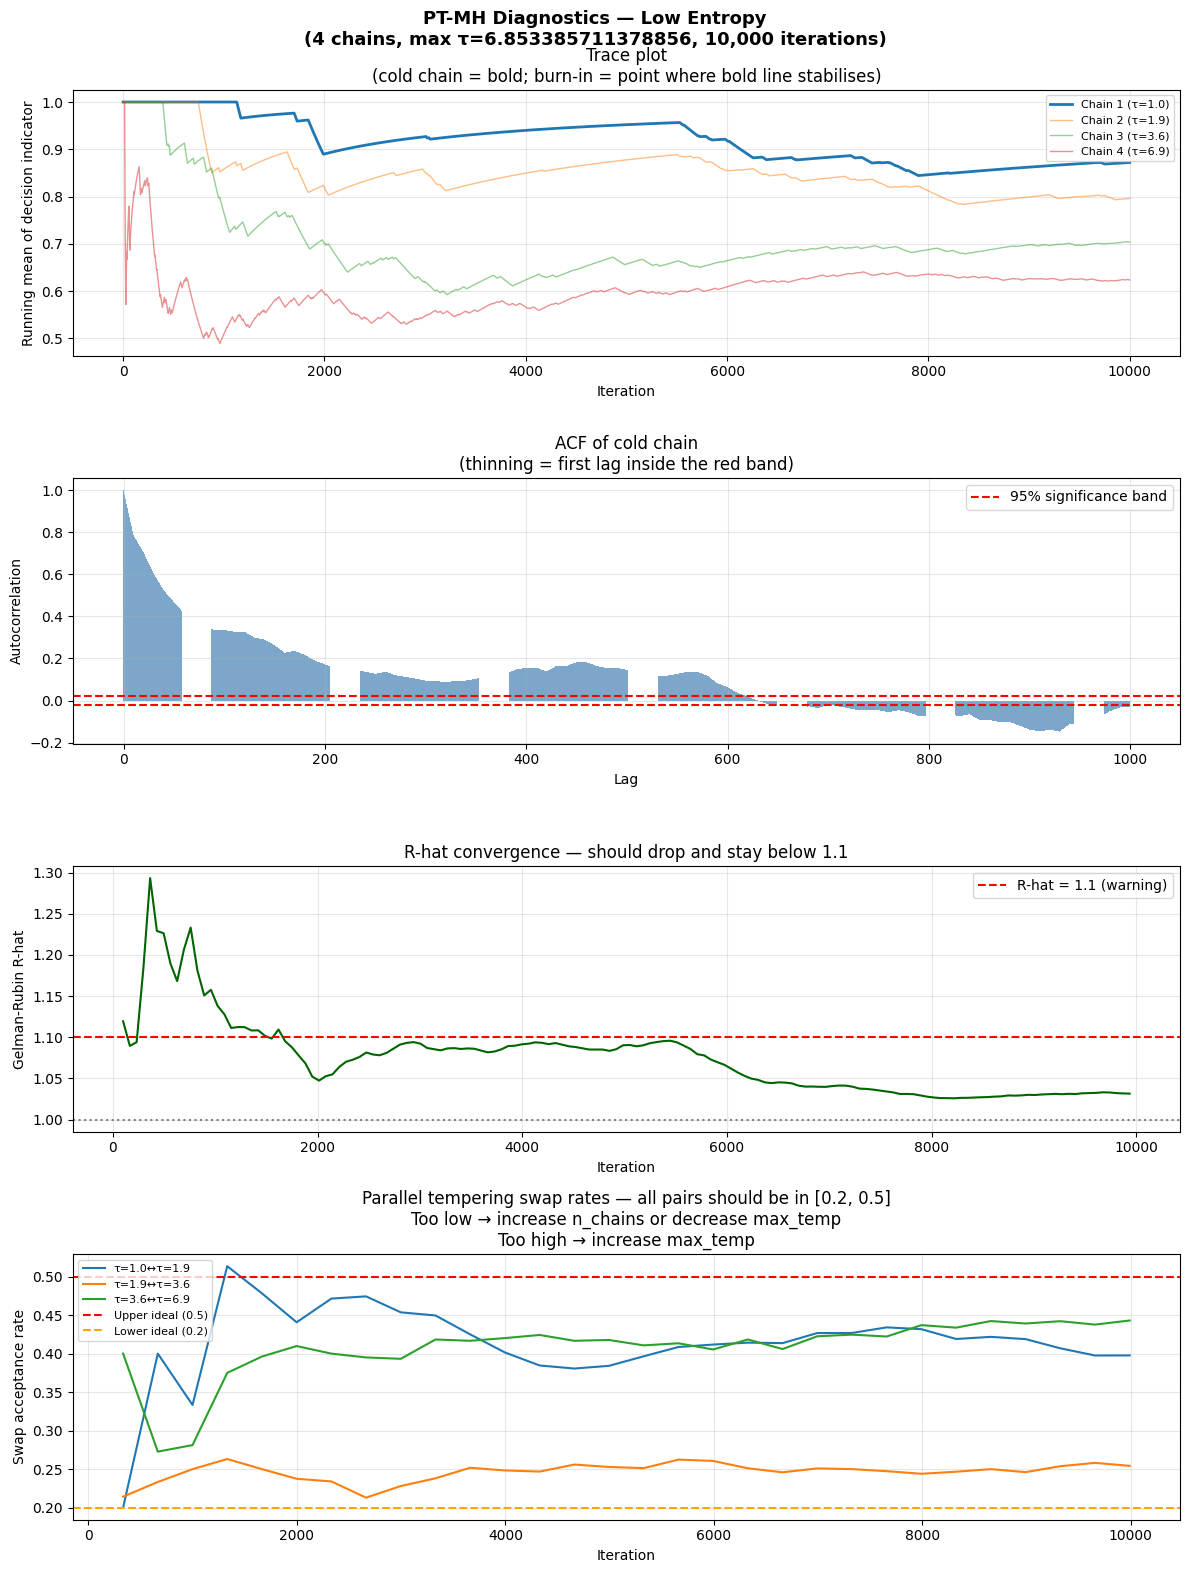


Network            : Low Entropy
Temperatures       : [1.   1.9  3.61 6.85]
Suggested burn-in  : 1919
Suggested thinning : 620
Final R-hat        : 1.0316  ✓ converged
  Swap τ=1.0↔τ=1.9 : 0.398  ✓
  Swap τ=1.9↔τ=3.6 : 0.254  ✓
  Swap τ=3.6↔τ=6.9 : 0.443  ✓


--- Starting Hill Climbing Harvest for Buckets: [0.8] ---
    [+] HARVEST SUCCESS (Restart 0, Step 16): Filled bucket 0.8 (Exact SDP: 0.8096)!
--- Harvest Complete. All buckets filled successfully! ---

Tuning max_temp for: High Entropy
  Starting search from max_temp=2.00 (H_norm=0.9628)
  max_temp=    2.00 → swap rates=[0.889 0.833 0.857]  min=0.833
  max_temp=    4.00 → swap rates=[0.529 1.    0.867]  min=0.529
  max_temp=    8.00 → swap rates=[0.667 0.722 0.85 ]  min=0.667
  max_temp=   16.00 → swap rates=[0.692 0.5   0.947]  min=0.500
  max_temp=   32.00 → swap rates=[0.533 0.667 0.95 ]  min=0.533
  max_temp=   64.00 → swap rates=[0.35  0.923 0.882]  min=0.350
  max_temp=  128.00 → swap rates=[0.571 0.778 1.   ]  min=0.571
 

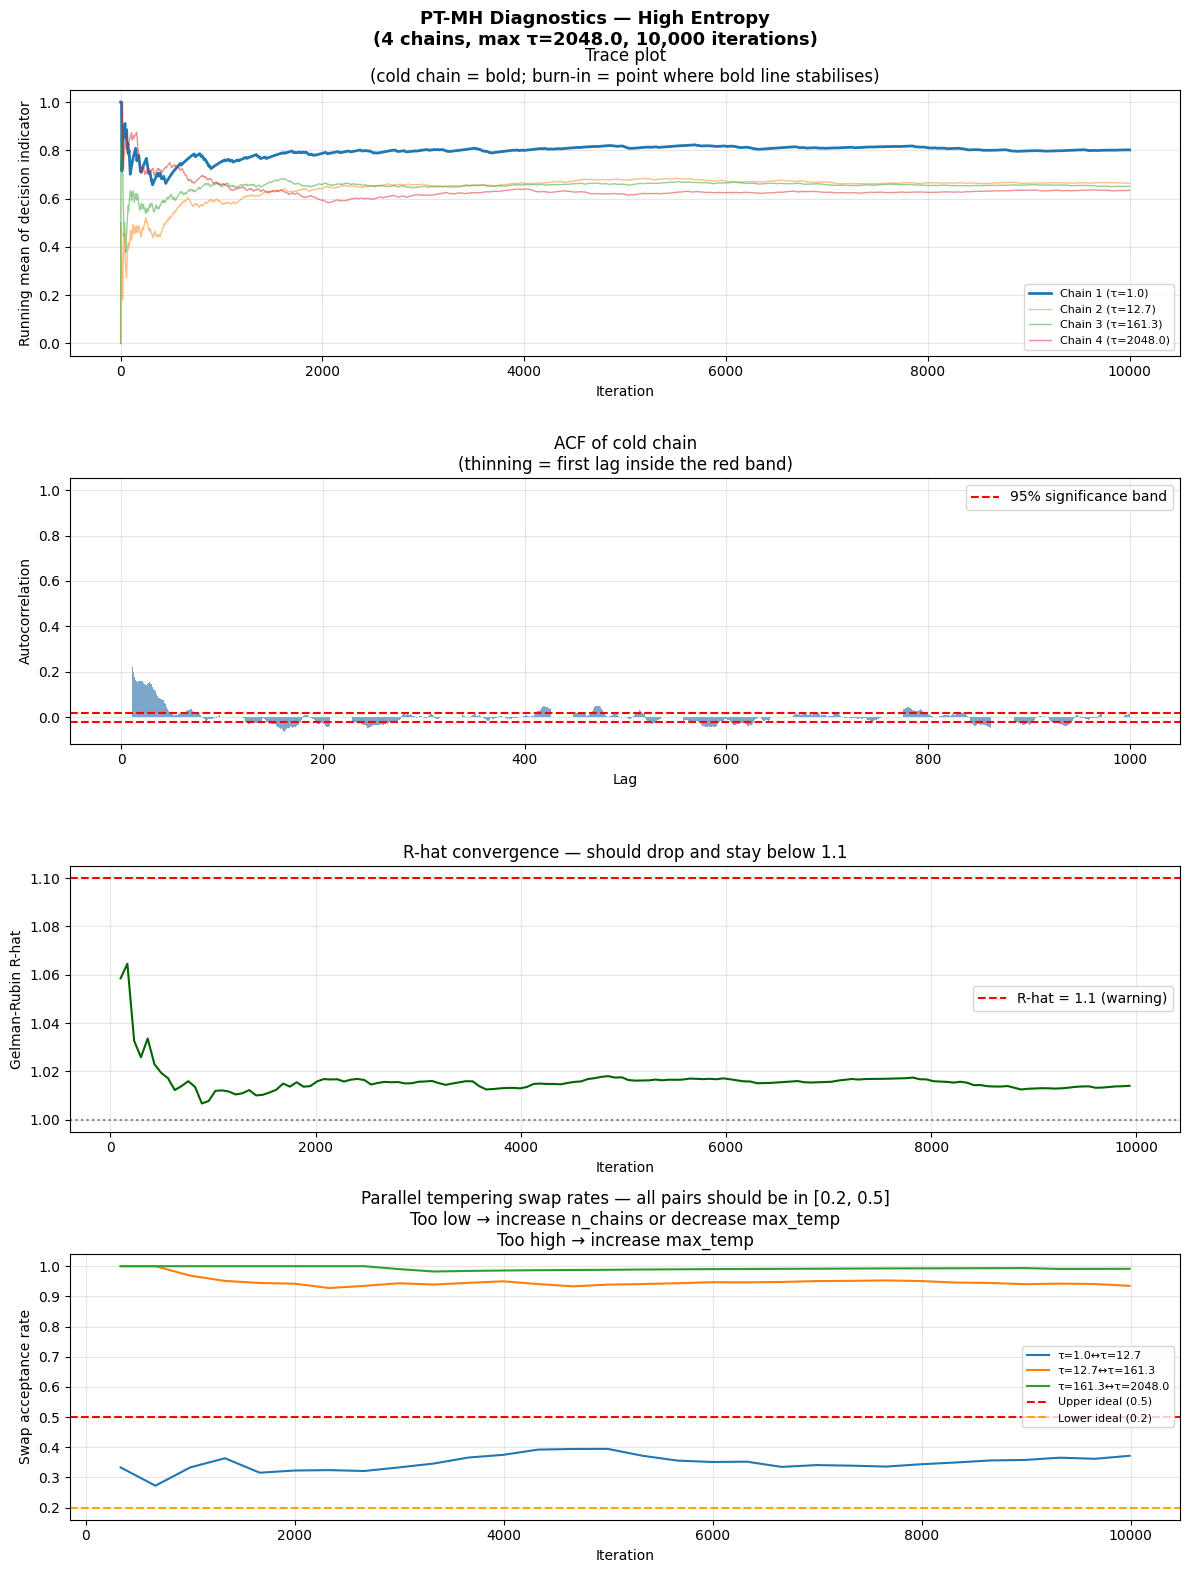


Network            : High Entropy
Temperatures       : [1.0000e+00 1.2700e+01 1.6127e+02 2.0480e+03]
Suggested burn-in  : 11
Suggested thinning : 51
Final R-hat        : 1.0140  ✓ converged
  Swap τ=1.0↔τ=12.7 : 0.371  ✓
  Swap τ=12.7↔τ=161.3 : 0.935  ✗ adjust max_temp
  Swap τ=161.3↔τ=2048.0 : 0.991  ✗ adjust max_temp



In [14]:
def tune_max_temp(bn, target, target_value, patient, threshold,
                  n_chains=4, pilot_iterations=500,
                  target_swap_min=0.2, target_swap_max=0.5,
                  max_search_iters=10, verbose=True):
    """
    Automatically tunes max_temp for parallel tempering by running short
    pilot chains and binary-searching until all adjacent swap rates fall
    within [target_swap_min, target_swap_max].

    Parameters
    ----------
    pilot_iterations : short run length per candidate max_temp — keep low
                       (300–500) since we only need swap rate estimates.
    max_search_iters : maximum number of tuning rounds before giving up.

    Returns
    -------
    float — tuned max_temp value.
    """

    hidden_vars     = [n for n in bn.nodes() if n not in patient and n != target]
    target_states   = bn.get_cpds(target).state_names[target]
    cpd_cache       = {n: bn.get_cpds(n) for n in bn.nodes()}
    children_cache  = {v: list(bn.get_children(v)) for v in hidden_vars}
    affected_cache  = {v: [v] + children_cache[v] for v in hidden_vars}
    evidence_states = [State(var, val) for var, val in patient.items()]
    sampler         = BayesianModelSampling(bn)

    # ── Helpers ───────────────────────────────────────────────────────────────

    def full_log_joint(h_dict, t_state):
        full = {**h_dict, **patient, target: t_state}
        lp = 0.0
        for cpd in cpd_cache.values():
            p = cpd.get_value(**{v: full[v] for v in cpd.variables})
            if p == 0.0:
                return float('-inf')
            lp += math.log(p)
        return lp

    def log_sum_joints(lj_dict):
        vals = [v for v in lj_dict.values() if v != float('-inf')]
        if not vals:
            return float('-inf')
        m = max(vals)
        return m + math.log(sum(math.exp(v - m) for v in vals))

    def local_log_delta(var, old_val, new_val, h_dict, t_state):
        full_old = {**h_dict, **patient, target: t_state}
        full_new = {**full_old, var: new_val}
        delta = 0.0
        for node in affected_cache[var]:
            cpd   = cpd_cache[node]
            cvars = cpd.variables
            p_old = cpd.get_value(**{v: full_old[v] for v in cvars})
            p_new = cpd.get_value(**{v: full_new[v] for v in cvars})
            if p_new == 0.0:
                return float('-inf')
            if p_old == 0.0:
                return float('inf')
            delta += math.log(p_new) - math.log(p_old)
        return delta

    def get_seed():
        while True:
            seed_df = sampler.likelihood_weighted_sample(
                size=100, evidence=evidence_states, show_progress=False
            )
            valid = seed_df[seed_df['_weight'] > 0]
            if not valid.empty:
                w = valid['_weight'].values.astype(float)
                w /= w.sum()
                row = valid.iloc[np.random.choice(len(valid), p=w)]
                return {v: row[v] for v in hidden_vars}

    # ── Pilot run: estimate swap rates for a given max_temp ──────────────────

    def estimate_swap_rates(max_temp_candidate):
        """Runs a short pilot chain and returns per-pair swap acceptance rates."""
        temps      = np.geomspace(1.0, max_temp_candidate, n_chains)
        chains     = [get_seed() for _ in range(n_chains)]
        chain_ljs  = [{t: full_log_joint(h, t) for t in target_states}
                      for h in chains]
        chain_logp = [log_sum_joints(lj) for lj in chain_ljs]

        n_pairs       = n_chains - 1
        swap_attempts = np.zeros(n_pairs, dtype=int)
        swap_accepts  = np.zeros(n_pairs, dtype=int)

        for i in range(pilot_iterations):

            # Tempered MH update for every chain
            for c in range(n_chains):
                var     = random.choice(hidden_vars)
                cur_val = chains[c][var]
                others  = [s for s in cpd_cache[var].state_names[var]
                           if s != cur_val]
                if not others:
                    continue
                new_val = random.choice(others)

                proposed_lj = {}
                recompute   = False
                for t in target_states:
                    if chain_ljs[c][t] == float('-inf'):
                        recompute = True
                        break
                    delta = local_log_delta(var, cur_val, new_val, chains[c], t)
                    if delta == float('inf'):
                        recompute = True
                        break
                    proposed_lj[t] = chain_ljs[c][t] + delta

                if recompute:
                    tmp         = {**chains[c], var: new_val}
                    proposed_lj = {t: full_log_joint(tmp, t) for t in target_states}

                proposed_log_p = log_sum_joints(proposed_lj)
                log_alpha = (proposed_log_p - chain_logp[c]) / temps[c]

                if log_alpha >= 0 or (
                    proposed_log_p != float('-inf') and
                    math.log(random.random()) < log_alpha
                ):
                    chains[c][var]  = new_val
                    chain_ljs[c]    = proposed_lj
                    chain_logp[c]   = proposed_log_p

            # Swap attempt every 10 iterations
            if i % 10 == 0 and n_chains > 1:
                c1 = random.randint(0, n_pairs - 1)
                c2 = c1 + 1
                swap_attempts[c1] += 1
                log_alpha_swap = (
                    (1.0 / temps[c1] - 1.0 / temps[c2]) *
                    (chain_logp[c2] - chain_logp[c1])
                )
                if (log_alpha_swap >= 0 or
                        math.log(random.random()) < log_alpha_swap):
                    chains[c1],     chains[c2]     = chains[c2],     chains[c1]
                    chain_ljs[c1],  chain_ljs[c2]  = chain_ljs[c2],  chain_ljs[c1]
                    chain_logp[c1], chain_logp[c2] = chain_logp[c2], chain_logp[c1]
                    swap_accepts[c1] += 1

        rates = np.where(
            swap_attempts > 0,
            swap_accepts / swap_attempts,
            np.nan
        )
        return rates

    # ── Binary search over max_temp ───────────────────────────────────────────
    # Invariant:
    #   lo → swap rates too HIGH (chains too similar, max_temp too low)
    #   hi → swap rates too LOW  (chains too far apart, max_temp too high)
    #
    # We start from the entropy-based heuristic as the lower bound and
    # keep doubling until we find an upper bound where rates are too low,
    # then binary search between lo and hi.

    h_norm  = mean_conditional_entropy(bn)
    lo      = max(2.0, 1.0 / h_norm)   # heuristic starting point
    hi      = lo

    if verbose:
        print(f"  Starting search from max_temp={lo:.2f} "
              f"(H_norm={h_norm:.4f})")

    # Phase 1: find an upper bound where at least one swap rate is too low
    for _ in range(max_search_iters):
        rates = estimate_swap_rates(hi)
        min_rate = np.nanmin(rates)
        if verbose:
            print(f"  max_temp={hi:8.2f} → swap rates={np.round(rates, 3)}  "
                  f"min={min_rate:.3f}")
        if min_rate < target_swap_min:
            break       # hi is now a valid upper bound
        hi *= 2.0       # still too high — double and retry
    else:
        if verbose:
            print(f"  Could not find upper bound — using max_temp={hi:.2f}")
        return hi

    # Phase 2: binary search between lo and hi
    for step in range(max_search_iters):
        mid   = math.sqrt(lo * hi)    # geometric midpoint (temp is log-scale)
        rates = estimate_swap_rates(mid)
        min_rate = np.nanmin(rates)
        max_rate = np.nanmax(rates)

        if verbose:
            print(f"  [{step+1}/{max_search_iters}] "
                  f"max_temp={mid:8.2f} → swap rates={np.round(rates, 3)}  "
                  f"min={min_rate:.3f}  max={max_rate:.3f}")

        all_in_range = np.all(
            (rates >= target_swap_min) & (rates <= target_swap_max)
        )
        if all_in_range:
            if verbose:
                print(f"\n  ✓ Converged: max_temp={mid:.2f}")
            return mid

        # All rates too high → chains too similar → need higher max_temp
        if max_rate > target_swap_max:
            lo = mid
        # Some rate too low → chains too far apart → need lower max_temp
        else:
            hi = mid

    best = math.sqrt(lo * hi)
    if verbose:
        print(f"\n  Search ended. Best estimate: max_temp={best:.2f}")
    return best


for model in [model1, model2]:
    target        = select_optimal_target_node(model)
    target_states = model.get_cpds(target).state_names[target]
    target_value  = target_states[1]

    available     = [n for n in model.nodes() if n != target]
    evidence_vars = random.sample(available, k=len(available) // 2)

    target_sdp    = 0.8
    harvested_data = harvest_patients_for_all_buckets(
        model, target, target_value, 0.5, evidence_vars, [target_sdp]
    )
    result         = harvested_data[target_sdp]
    patient, _     = result

    print(f"\n{'='*55}")
    print(f"Tuning max_temp for: {model.name}")
    max_temp = tune_max_temp(
        model, target, target_value, patient, threshold=0.5,
        n_chains=4, pilot_iterations=500, max_search_iters=10
    )

    print(f"\nRunning PT-MH diagnostics for: {model.name}")
    n_iters = 10_000 if model.name == 'Low Entropy' else 10_000

    diag = run_pt_mcmc_diagnostics(
        model, target, target_value, patient, threshold=0.5,
        n_iterations=n_iters, n_chains=4, max_temp=max_temp
    )

In [15]:
model1_entropy = mean_conditional_entropy(model1)
model2_entropy = mean_conditional_entropy(model2)
print(f"\nMean conditional entropy (H_norm):")
print(f"  {model1.name}: {model1_entropy:.4f}")
print(f"  {model2.name}: {model2_entropy:.4f}")


Mean conditional entropy (H_norm):
  Low Entropy: 0.3182
  High Entropy: 0.9628
